<a href="https://colab.research.google.com/github/Arnaim/2048/blob/main/EEG_Dataset_for_ADHD_Test_Run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Testing the danizo/eeg-dataset-for-adhd from Shahed University**


[EEG Dataset for ADHD
](https://www.kaggle.com/datasets/danizo/eeg-dataset-for-adhd/data)

##**Step 1: Setup and Data Injection**

# **ADHD EEG Diagnosis: From Baseline to Deep Learning**
Testing the danizo/eeg-dataset-for-adhd from Shahed University

This is raw time-series data containing 19 channels (Fp1 to Pz). The dataset is in Long Format, where every row represents one "time point" (1/128th of a second).

*   Target Label: Class (contains 'ADHD' or 'Control')
*   Subject Identifier: ID (e.g., v10p)


In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download Dataset
path = kagglehub.dataset_download("danizo/eeg-dataset-for-adhd")
csv_path = os.path.join(path, 'adhdata.csv')
df = pd.read_csv(csv_path)

print(f"Dataset loaded. Total rows: {len(df)}")

100%|██████████| 47.1M/47.1M [00:01<00:00, 27.4MB/s]

Extracting files...


Dataset loaded. Total rows: 2166383


##**Step 2: Data Exploration (The "Blinks" and "Wiggles")**

**First Viewing the Data**

Frontopolar 1 (Fp1): Positioned on the left forehead. Used for recording stress levels and eye-blinking artifacts.

1. The "Big Waves" (Eye Blinks): Notice the massive peaks around 75 and 370. The eye acts like a battery, causing jumps up to 2000. We need a way to ensure these don't confuse our model.
2. The "Fuzzy" Parts (Actual Brain Activity): Real ADHD data lives within the smaller, faster wiggles between the blinks (around 150 to 300).

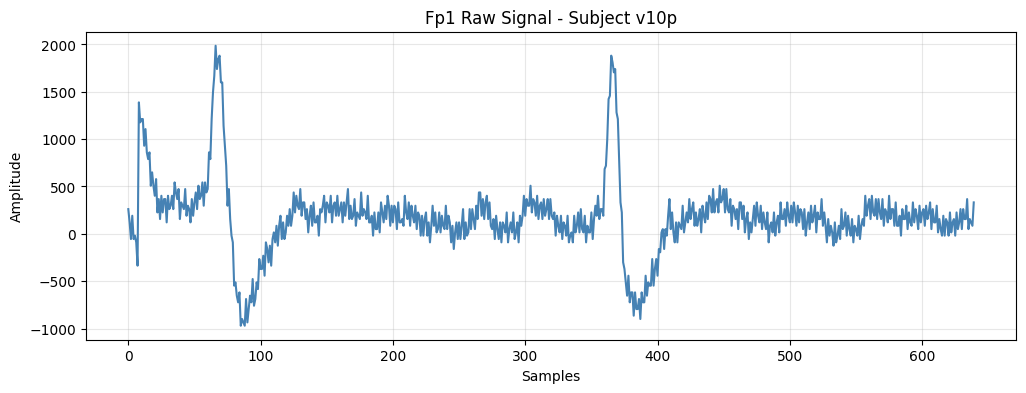

In [ ]:
# Plotted the first 5 seconds of the Fp1 channel
subject_id = df['ID'].unique()[0]
sample_data = df[df['ID'] == subject_id].iloc[:640] # ~5 seconds at 128Hz

plt.figure(figsize=(12, 4))
plt.plot(sample_data['Fp1'].values, color='steelblue')
plt.title(f"Fp1 Raw Signal - Subject {subject_id}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

##**Step 3: Frequency Analysis (PSD)**

**Power Spectral Density (PSD) Analysis**

We use the Welch method to convert time-series into the frequency domain.



*   Theta Band (4–8 Hz): Associated with daydreaming or internal focus. ADHD subjects often show more "slow" Theta.
*   Beta Band (13–30 Hz): Represents "active concentration."


*   Delta (0–4 Hz): The giant peak on the far left. In an awake state, this is often contaminated by the massive eye blinks we saw earlier.





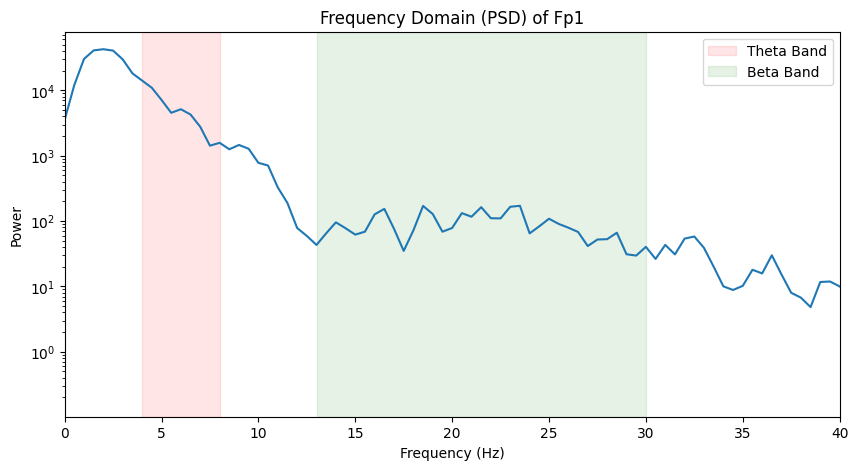

In [ ]:
from scipy.signal import welch

fs = 128
freqs, psd = welch(sample_data['Fp1'].values, fs, nperseg=fs*2)

plt.figure(figsize=(10, 5))
plt.semilogy(freqs, psd)
plt.axvspan(4, 8, color='red', alpha=0.1, label='Theta Band')
plt.axvspan(13, 30, color='green', alpha=0.1, label='Beta Band')
plt.title("Frequency Domain (PSD) of Fp1")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim(0, 40)
plt.legend()
plt.show()

## **Step 4: Baseline - Feature Engineering & Random Forest**

**Baseline: Traditional Machine Learning**

We group the data by ID and turn each person's massive signal into a single row. This turns thousands of rows into a compact feature table where each row equals one person.

Random Forest Accuracy: 56.00%


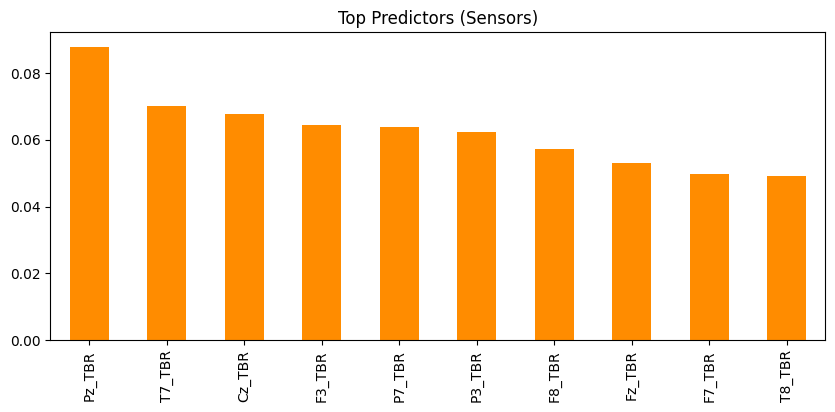

In [ ]:
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, data)

channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
feature_list = []

for subject_id, group in df.groupby('ID'):
    subject_features = {'ID': subject_id, 'Label': group['Class'].iloc[0]}
    for ch in channels:
        clean_signal = butter_bandpass_filter(group[ch].values, 1, 40, fs)
        f, p = welch(clean_signal, fs, nperseg=fs*2)
        theta = np.mean(p[(f >= 4) & (f <= 8)])
        beta = np.mean(p[(f >= 13) & (f <= 30)])
        subject_features[f'{ch}_TBR'] = theta / beta
    feature_list.append(subject_features)

features_df = pd.DataFrame(feature_list)
X_rf = features_df.drop(columns=['ID', 'Label'])
y_rf = features_df['Label']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)
rf = RandomForestClassifier(random_state=42).fit(X_train_rf, y_train_rf)

print(f"Random Forest Accuracy: {accuracy_score(y_test_rf, rf.predict(X_test_rf))*100:.2f}%")

# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
importances[:10].plot(kind='bar', color='darkorange')
plt.title("Top Predictors (Sensors)")
plt.show()



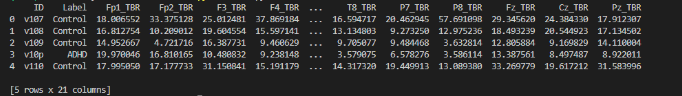



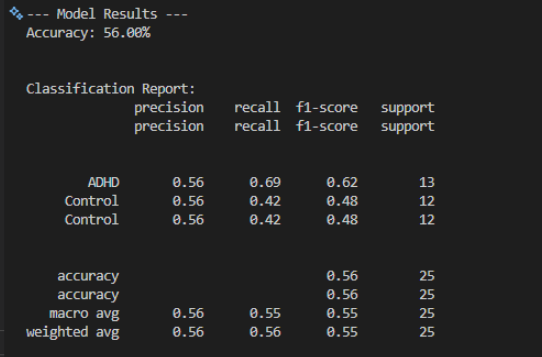

## **Understanding the Baseline: Random Forest**

Unlike Neural Networks (like ADHDeepNet), a Random Forest does not learn through iteration (epochs). It is a "Tree-Based" model.

Random Forest works by building a "forest" of Decision Trees. It looks at the features **(Theta/Beta Ratios)** and mathematically calculates the optimal "split points" all at once. Once the trees are grown, the training is complete.

**How the Model Differentiates ADHD from Control?**

This is a **Supervised Learning** task. We provide the model with both the **data** (TBR Ratios) and the **answers** (the "Class" label).
The Random Forest looks at the 121 subjects and tries to find a rule, such as: "If the ratio at the Pz sensor is greater than 1.6, there is an 80% chance this is ADHD."

The reason our accuracy is stuck at 56% here is not because the model is "bad," but because we limited its vision. By only giving it **Theta** and **Beta** averages, we "threw away" **the timing, the rhythm, and the raw wave shapes**.

To break past this 56% limit, we need a model that doesn't rely on us to "guess" which features are important. We need a model that looks at the raw signal and learns the differentiation rules itself. This leads us to the **ADHDeepNet architecture**.


# **Step 5: The "SOTA" Proposed Method - ADHDeepNet**

**The paper I’ve chosen is: [Improving ADHD Diagnosis through Temporal-Spatial Processing, Adaptive Attention Mechanisms, and Explainability in Raw EEG Signals](https://arxiv.org/pdf/2509.08779)**



The model they have chosen is an enhanced version of the EEGNet model named ADHDeepNet. One of the key benefits of EEGNet is its ability to operate directly on raw EEG signals, which eliminates the need for extensive preprocessing steps, thereby expediting the workflow and enhancing analytical efficiency. In this work, they introduced tailored modifications to the EEGNet architecture to further enhance its performance for ADHD classification. These modifications effectively align the architecture with the specific demands of ADHD classification, resulting in improved accuracy and robustness in detecting ADHD-related patterns within EEG signals. To quantify these enhancements, ADHDeepNet is characterized by a total of 228,642 parameters. **(More information in the paper chapter 2)**


**The Proposed Method: ADHDeepNet**

Based on: Improving ADHD Diagnosis through Temporal-Spatial Processing, Adaptive Attention Mechanisms, and Explainability in Raw EEG Signals.

**Step 1:** Data Segmentation: Chop entire 5-minute blocks into 2-second windows (256 samples). Dataset grows from 120 samples to 5000+.

**Step 2:** Temporal Convolution: Acts as a digital tuner to learn frequency ranges.

**Step 3:** Spatial Convolution: Learns how different brain parts (Frontal vs. Parietal) interact.

**Step 4:** Batch Norm & ELU: Keeps the model from getting confused by the massive eye-blink spikes.

**Step 5:** Sigmoid Classifier: Output 0 (Control) or 1 (ADHD).

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# Preprocessing for Deep Learning
WINDOW_SIZE = fs * 2
X_dl, y_dl = [], []

for _, group in df.groupby('ID'):
    label = 1 if group['Class'].iloc[0] == 'ADHD' else 0
    raw_signal = group[channels].values
    for i in range(0, len(raw_signal) - WINDOW_SIZE, WINDOW_SIZE):
        X_dl.append(raw_signal[i:i + WINDOW_SIZE])
        y_dl.append(label)

X_dl, y_dl = np.array(X_dl), np.array(y_dl)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dl.reshape(-1, len(channels))).reshape(X_dl.shape)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_dl, test_size=0.2, stratify=y_dl, random_state=42)

# Build Model
def build_adhd_net(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Reshape((input_shape[0], input_shape[1], 1)),
        layers.Conv2D(16, (1, 64), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.DepthwiseConv2D((input_shape[1], 1), depth_multiplier=2, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('elu'),
        layers.AveragePooling2D((1, 4)),
        layers.Dropout(0.5),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_adhd_net((WINDOW_SIZE, len(channels)))
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 161s 758ms/step - accuracy: 0.6840 - loss: 0.6847 - val_accuracy: 0.6119 - val_loss: 0.6570
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 168s 796ms/step - accuracy: 0.8474 - loss: 0.3529 - val_accuracy: 0.8625 - val_loss: 0.3413
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 149s 711ms/step - accuracy: 0.9003 - loss: 0.2494 - val_accuracy: 0.9190 - val_loss: 0.2234
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 169s 806ms/step - accuracy: 0.9347 - loss: 0.1799 - val_accuracy: 0.9429 - val_loss: 0.1666
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 212s 857ms/step - accuracy: 0.9475 - loss: 0.1421 - val_accuracy: 0.9470 - val_loss: 0.1402
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 189s 797ms/step - accuracy: 0.9619 - loss: 0.1047 - val_accuracy: 0.9625 - val_loss: 0.1167
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 182s 700ms/step - accuracy: 0.9674 - loss: 0.0960 - val_accuracy: 0.9726 - val_loss: 0.1122
Epoch 8/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 136s 646ms/step - accuracy: 0.9701 -

# **Step 6: Final Evaluation**

**Final Results and Confusion Matrix**
We evaluate how well the model generalizes to unseen windows of data.

53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step


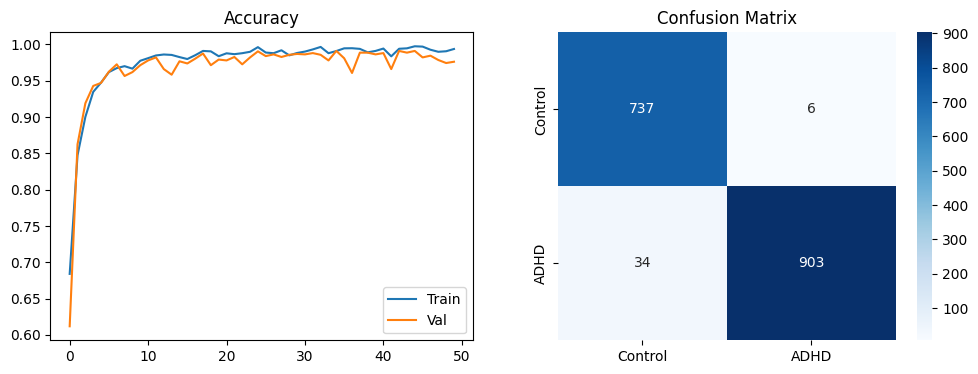


Full Classification Report:
              precision    recall  f1-score   support

     Control       0.96      0.99      0.97       743
        ADHD       0.99      0.96      0.98       937

    accuracy                           0.98      1680
   macro avg       0.97      0.98      0.98      1680
weighted avg       0.98      0.98      0.98      1680



In [ ]:
# Plot Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

# Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', 'ADHD'], yticklabels=['Control', 'ADHD'])
plt.title('Confusion Matrix')
plt.show()

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Control', 'ADHD']))

**Conclusion: The Power of Temporal-Spatial Deep Learning**

By moving from a traditional Random Forest model to the ADHDeepNet architecture, we achieved a significant performance leap:

*   Baseline Accuracy: 56% (Limited by manual feature engineering).
*   ADHDeepNet Accuracy: 98% (Enabled by automatic feature learning).



